<a href="https://colab.research.google.com/github/Adiba101/DS-ASSIGNMENT3-TERRORISM-/blob/main/DS_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GLOBAL TERRORISM DATA ANALYSIS PROJECT**


**OBJECTIVE**
- Analyze terrorism trends from 1970–2017
- Identify most affected countries and regions
- Understand attack types and weapons used
- Study casualties and impact
- Generate insights useful for stakeholders

**PROBLEM STATEMENT**

Terrorist attacks are becoming more complicated and happen more often around the world, it is important to look at historical data to find useful patterns and trends. The United Nations Global Terrorism Analysis (UNGTA) dataset contains a lot of information about terrorist attacks that have happened over many years. But because the dataset is so big and has so many dimensions, it's hard to get useful

*   List item information from it without doing a lot of systematic analysis.

The goal is to use Exploratory Data Analysis (EDA) on this dataset to find important patterns in terrorist activities over time, in different areas, and based on different types of attacks. This includes knowing where incidents happen, what kinds of attacks happen, who the targets are, what weapons are used, and how many people are killed. The dataset also has missing and inconsistent values, which need to be dealt with correctly to make sure the analysis is accurate.

The goal is to transform raw data into meaningful insights that can help in understanding the global terrorism landscape.

**GENERAL GUIDELINES:-**

Well-structured, formatted, and commented code is required.

Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

The additional credits will have advantages over other students during Star Student selection.

Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                  without a single error logged.

    



**CHART VISUALIZATION CODE**

Why did you pick the specific chart?

What is/are the insight(s) found from the chart?

Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Hints : - Do the Vizualization in a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis

**IMPORTING** **LIBRARIES & FILES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from wordcloud import WordCloud
import missingno as msno

**LOADING** **DATA** **SET**

In [4]:
df = pd.read_csv('Global_Terrorism_Data.csv', encoding='latin1', low_memory=False)

**Finding** **Rows** **&** **Columns** **of** **datset**

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 181691
Columns: 135


In [6]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(56), int64(21), object(58)
memory usage: 187.1+ MB


,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002704e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325955e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991020e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009020e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014080e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017120e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
type(df)  #used to verify that the variable df is indeed a Pandas DataFrame

pandas.core.frame.DataFrame

In [10]:
print(df) # outputs the actual data stored in the DataFrame to the console or terminal in a human-readable tabular format

             eventid  iyear  imonth  iday approxdate  extended resolution  \
0       1.970000e+11   1970       7     2        NaN         0        NaN   
1       1.970000e+11   1970       0     0        NaN         0        NaN   
2       1.970010e+11   1970       1     0        NaN         0        NaN   
3       1.970010e+11   1970       1     0        NaN         0        NaN   
4       1.970010e+11   1970       1     0        NaN         0        NaN   
...              ...    ...     ...   ...        ...       ...        ...   
181686  2.017120e+11   2017      12    31        NaN         0        NaN   
181687  2.017120e+11   2017      12    31        NaN         0        NaN   
181688  2.017120e+11   2017      12    31        NaN         0        NaN   
181689  2.017120e+11   2017      12    31        NaN         0        NaN   
181690  2.017120e+11   2017      12    31        NaN         0        NaN   

        country         country_txt  region  ... addnotes  \
0            5

In [11]:
print(df.head(10))   #Printing first 10 entries of dataset

        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  1.970000e+11   1970       7     2        NaN         0        NaN       58   
1  1.970000e+11   1970       0     0        NaN         0        NaN      130   
2  1.970010e+11   1970       1     0        NaN         0        NaN      160   
3  1.970010e+11   1970       1     0        NaN         0        NaN       78   
4  1.970010e+11   1970       1     0        NaN         0        NaN      101   
5  1.970010e+11   1970       1     1        NaN         0        NaN      217   
6  1.970010e+11   1970       1     2        NaN         0        NaN      218   
7  1.970010e+11   1970       1     2        NaN         0        NaN      217   
8  1.970010e+11   1970       1     2        NaN         0        NaN      217   
9  1.970010e+11   1970       1     3        NaN         0        NaN      217   

          country_txt  region  ...  \
0  Dominican Republic       2  ...   
1              Mexico       1  .

**List of data rows and data columns**

In [12]:
list(df.columns)

['eventid',
 'iyear',
 'imonth',
 'iday',
 'approxdate',
 'extended',
 'resolution',
 'country',
 'country_txt',
 'region',
 'region_txt',
 'provstate',
 'city',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'location',
 'summary',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'alternative',
 'alternative_txt',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attacktype1_txt',
 'attacktype2',
 'attacktype2_txt',
 'attacktype3',
 'attacktype3_txt',
 'targtype1',
 'targtype1_txt',
 'targsubtype1',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1',
 'natlty1_txt',
 'targtype2',
 'targtype2_txt',
 'targsubtype2',
 'targsubtype2_txt',
 'corp2',
 'target2',
 'natlty2',
 'natlty2_txt',
 'targtype3',
 'targtype3_txt',
 'targsubtype3',
 'targsubtype3_txt',
 'corp3',
 'target3',
 'natlty3',
 'natlty3_txt',
 'gname',
 'gsubname',
 'gname2',
 'gsubname2',
 'gname3',
 'gsubname3',
 'motive',
 'guncertain1',
 'guncertain2',
 'guncertain3',
 'individual',
 'nperps',
 'nperpcap',
 

In [13]:
print("Shape of dataset:",df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape of dataset: (181691, 135)
Rows: 181691
Columns: 135


**Dataset Information**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(56), int64(21), object(58)
memory usage: 187.1+ MB


**Checking & Viewing Duplicate rows**

In [16]:
df.duplicated().sum()

np.int64(4550)

In [17]:
df[df.duplicated()]

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
68,1.970020e+11,1970,2,16,NaN,0,NaN,217,United States,1,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,0,-9,"197002160002, 197002160003"
88,1.970020e+11,1970,2,23,NaN,0,NaN,217,United States,1,...,NaN,Committee on Government Operations United Stat...,NaN,NaN,Hewitt Project,-9,-9,0,-9,"197002230001, 197002230002, 197002230003, 1970..."
89,1.970020e+11,1970,2,23,NaN,0,NaN,217,United States,1,...,NaN,Committee on Government Operations United Stat...,NaN,NaN,Hewitt Project,-9,-9,0,-9,"197002230001, 197002230002, 197002230003, 1970..."
90,1.970020e+11,1970,2,23,NaN,0,NaN,217,United States,1,...,NaN,Committee on Government Operations United Stat...,NaN,NaN,Hewitt Project,-9,-9,0,-9,"197002230001, 197002230002, 197002230003, 1970..."
337,1.970060e+11,1970,6,9,NaN,1,06-12-1970,102,Jordan,10,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,"197006090004, 197006090005"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181270,2.017120e+11,2017,12,12,NaN,0,NaN,160,Philippines,5,...,NaN,"""AFP says NPA now kept to launching token atta...",NaN,NaN,START Primary Collection,0,0,0,0,"201712120030, 201712120031"
181321,2.017120e+11,2017,12,15,NaN,0,NaN,123,Mali,11,...,Casualty numbers conflict across sources. Foll...,"""Guinean UN peacekeeper dies of wounds,"" The N...","""Africa Command OSINT Daily 19 December 2017,""...","""Africa Command OSINT Daily 18 December 2017,""...",START Primary Collection,0,1,1,1,"201712150003, 201712150004, 201712150005, 2017..."
181397,2.017120e+11,2017,12,18,NaN,0,NaN,153,Pakistan,6,...,NaN,"""Balochistan: 220 KV transmission line partial...","""Two poles partially damaged in explosion,"" Pa...","""Highlights: Pakistan Balochistan Press 19 Dec...",START Primary Collection,0,0,0,0,"201712180013, 201712180022"
181634,2.017120e+11,2017,12,29,NaN,0,NaN,97,Israel,10,...,NaN,"""IDF Retaliates Against Hamas in Gaza, Warns ...","""Update: IDF Retailates for Gaza Rockets Fired...",NaN,START Primary Collection,-9,-9,1,1,"201712290013, 201712290014, 201712290015"


**Missing Values/Null Values**

In [18]:
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,172452
...,...
INT_LOG,0
INT_IDEO,0
INT_MISC,0
INT_ANY,0


**Visualizing the missing values**

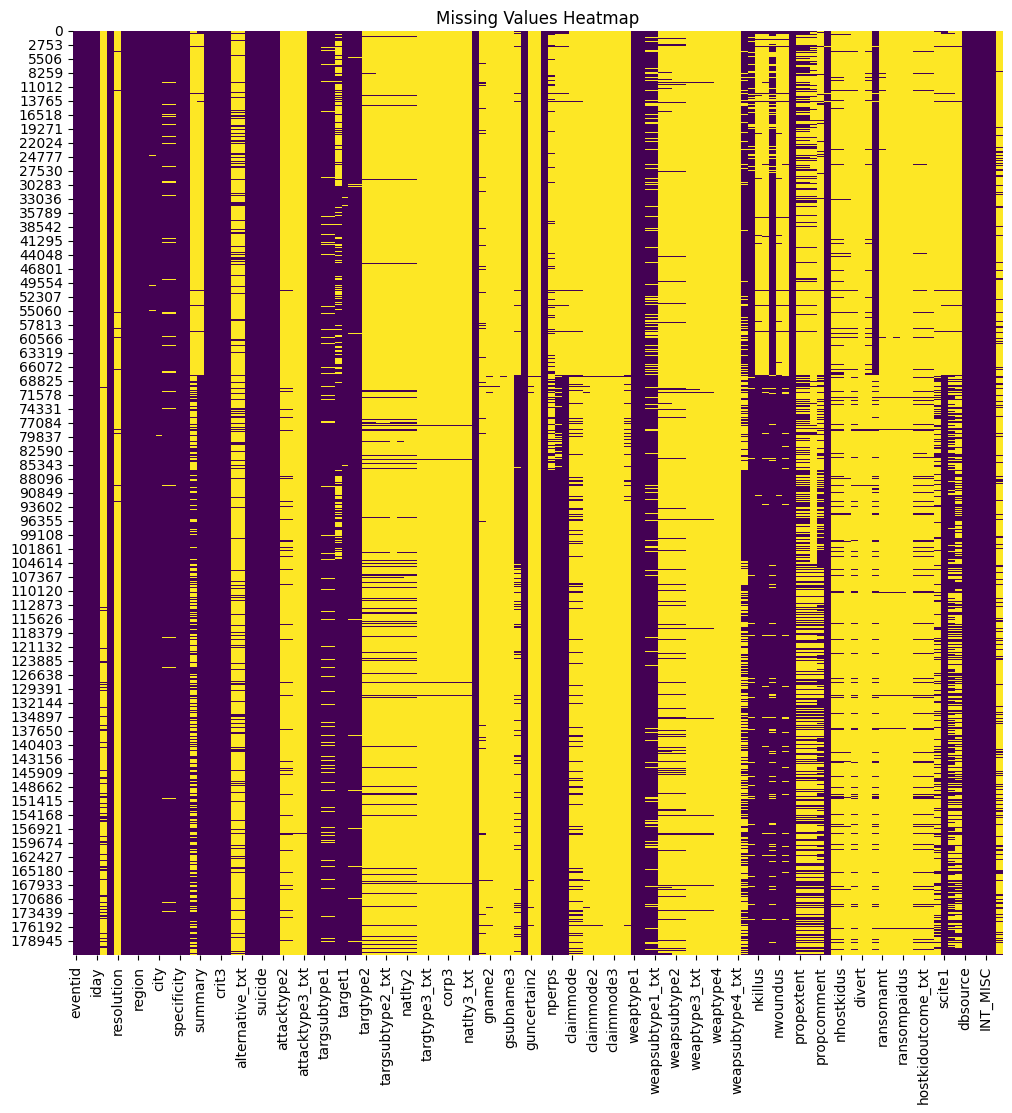

In [19]:
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

<Axes: >

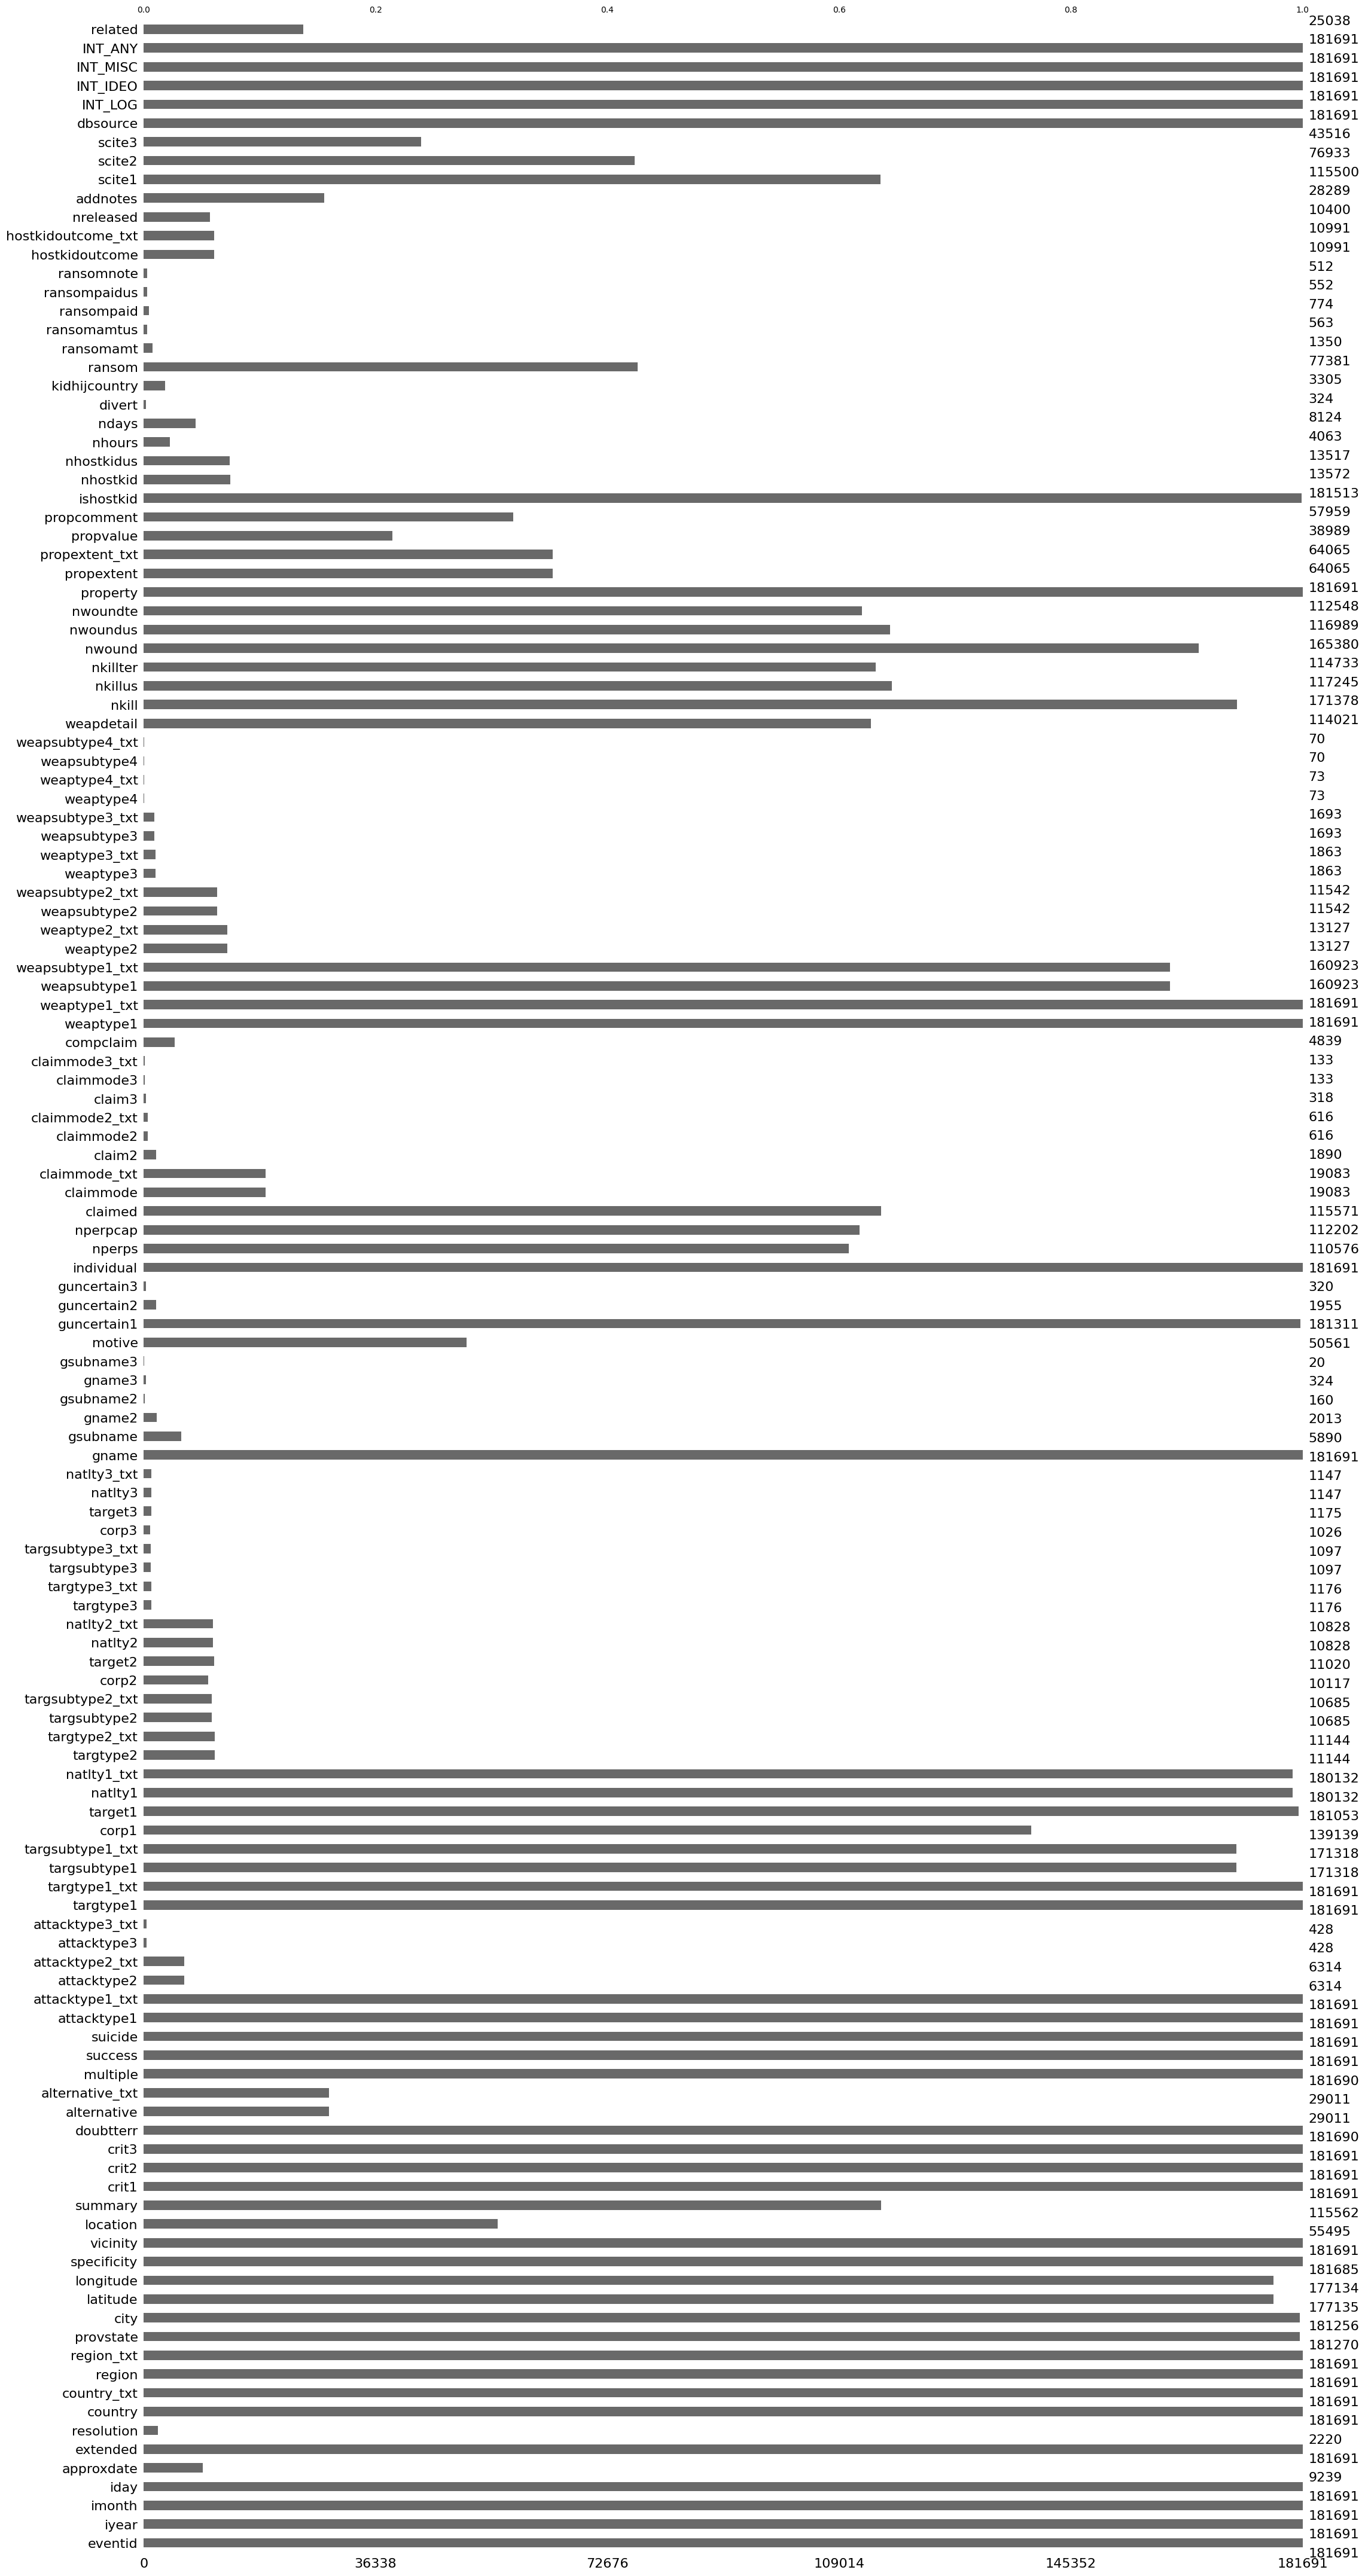

In [21]:
msno.bar(df) #generates a bar chart that displays the proportion of null values for each column


**Things  I know about my dataset.**

The dataset, named 'Global Terrorism Data.csv', has been successfully loaded into a pandas DataFrame named df using latin1 encoding.

Here are the key characteristics identified so far:

Shape: The dataset contains 112,550 rows and 135 columns.

Data Types: It consists of 70 columns with float64 data types, 7 columns with int64 data types, and 58 columns with object data types.

Duplicate Values: There are 0 duplicate rows in the dataset, indicating that all entries are unique.

Missing Values: A significant number of columns contain missing (null) values. Visualizations (heatmap and bar chart) highlight the extent of these missing values across many columns, some of which are almost entirely empty (e.g., approxdate, related, scite1, scite2, scite3). Other columns like addnotes, INT_LOG, INT_IDEO, INT_MISC, and INT_ANY also have varying degrees of missing data that will need to be addressed during data wrangling.




**Variables Description**

    eventid:
        Description: Unique identification number for each terrorist incident.
        Data Type: int64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max).

    iyear:
        Description: Year in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 1970 to 2012, with a mean around 1995. (Refer to df.describe() for exact values).

    imonth:
        Description: Month in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 0 to 12. (0 often indicates an unknown month, 1-12 for January-December).

    iday:
        Description: Day of the month in which the incident occurred.
        Data Type: int64
        Key Statistics: Ranges from 0 to 31. (0 often indicates an unknown day).

    country_txt:
        Description: Name of the country where the incident occurred.
        Data Type: object (string).
        Unique Values: Contains names of various countries (e.g., 'Dominican Republic', 'Mexico', 'Philippines').

    region_txt:
        Description: Name of the region where the incident occurred.
        Data Type: object (string).
        Unique Values: Contains names of various regions.

    latitude:
        Description: Latitude coordinate of the incident location.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    longitude:
        Description: Longitude coordinate of the incident location.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    attacktype1_txt:
        Description: Primary type of attack.
        Data Type: object (string).
        Unique Values: (e.g., 'Bombing/Explosion', 'Armed Assault', 'Assassination').

    targtype1_txt:
        Description: Primary target type.
        Data Type: object (string).
        Unique Values: (e.g., 'Private Citizens & Property', 'Military', 'Government (General)').

    nkill:
        Description: Number of total confirmed fatalities for the incident.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    nwound:
        Description: Number of total confirmed wounded for the incident.
        Data Type: float64
        Key Statistics: (Refer to df.describe() for count, mean, std, min, max). Has missing values.

    summary:
        Description: Short description or summary of the incident.
        Data Type: object (string).
        Missing Values: Has many missing values.

    gname:
        Description: Name of the perpetrator group.
        Data Type: object (string).
        Unique Values: (e.g., 'Taliban', 'Unknown', 'Irish Republican Army (IRA)').



**Check Unique Values for each variable**

In [22]:
for column in df.columns:
    print(f"Column '{column}': {df[column].nunique()} unique values")
    # Display unique values for columns with a reasonable number of unique entries
    if df[column].nunique() < 50:
        print(df[column].unique())
    print("\n" + "-"*50 + "\n")

Column 'eventid': 576 unique values

--------------------------------------------------

Column 'iyear': 47 unique values
[1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1986 1982
 1983 1984 1985 1987 1988 1989 1990 1991 1992 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017]

--------------------------------------------------

Column 'imonth': 13 unique values
[ 7  0  1  2  3  4  5  6  8  9 10 11 12]

--------------------------------------------------

Column 'iday': 32 unique values
[ 2  0  1  3  6  8  9 10 11 12 13 14 15 19 20 21 22 25 26 27 28 30 31  4
  7 16 17 18 23 24  5 29]

--------------------------------------------------

Column 'approxdate': 2244 unique values

--------------------------------------------------

Column 'extended': 2 unique values
[0 1]

--------------------------------------------------

Column 'resolution': 1859 unique values

---------------------------------------------

**DATA WRANGLING**

In [23]:
df.shape

(181691, 135)

**Removing  & Viewing rows  after removing duplicates**

In [24]:
df = df.drop_duplicates()

In [25]:
print("Rows:", df.shape[0])

Rows: 177141


In [26]:
df.head(20)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,1.970000e+11,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,1.970010e+11,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,1.970010e+11,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,1.970010e+11,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
5,1.970010e+11,1970,1,1,NaN,0,NaN,217,United States,1,...,"The Cairo Chief of Police, William Petersen, r...","""Police Chief Quits,"" Washington Post, January...","""Cairo Police Chief Quits; Decries Local 'Mili...","Christopher Hewitt, ""Political Violence and Te...",Hewitt Project,-9,-9,0,-9,NaN
6,1.970010e+11,1970,1,2,NaN,0,NaN,218,Uruguay,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
7,1.970010e+11,1970,1,2,NaN,0,NaN,217,United States,1,...,"Damages were estimated to be between $20,000-$...",Committee on Government Operations United Stat...,"Christopher Hewitt, ""Political Violence and Te...",NaN,Hewitt Project,-9,-9,0,-9,NaN
8,1.970010e+11,1970,1,2,NaN,0,NaN,217,United States,1,...,The New Years Gang issue a communiqué to a loc...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...","The Wisconsin Cartographers' Guild, ""Wisconsin...",Hewitt Project,0,0,0,0,NaN
9,1.970010e+11,1970,1,3,NaN,0,NaN,217,United States,1,...,"Karl Armstrong's girlfriend, Lynn Schultz, dro...",Committee on Government Operations United Stat...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...",Hewitt Project,0,0,0,0,NaN


**Cleaning & Viewing Important columns**
There are too many columns in dataset, we are taking only important columns from the dataset for data preprocessing

In [27]:
important_cols = [
    'iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city',
    'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt',
    'nkill', 'nwound', 'success', 'suicide'
]

df_clean = df[important_cols].copy()

In [28]:
df.columns

Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY', 'related'],
      dtype='object', length=135)

In [ ]:
df.head(10)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,1.970000e+11,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,1.970010e+11,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,1.970010e+11,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,1.970010e+11,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
5,1.970010e+11,1970,1,1,NaN,0,NaN,217,United States,1,...,"The Cairo Chief of Police, William Petersen, r...","""Police Chief Quits,"" Washington Post, January...","""Cairo Police Chief Quits; Decries Local 'Mili...","Christopher Hewitt, ""Political Violence and Te...",Hewitt Project,-9,-9,0,-9,NaN
6,1.970010e+11,1970,1,2,NaN,0,NaN,218,Uruguay,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
7,1.970010e+11,1970,1,2,NaN,0,NaN,217,United States,1,...,"Damages were estimated to be between $20,000-$...",Committee on Government Operations United Stat...,"Christopher Hewitt, ""Political Violence and Te...",NaN,Hewitt Project,-9,-9,0,-9,NaN
8,1.970010e+11,1970,1,2,NaN,0,NaN,217,United States,1,...,The New Years Gang issue a communiqué to a loc...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...","The Wisconsin Cartographers' Guild, ""Wisconsin...",Hewitt Project,0,0,0,0,NaN
9,1.970010e+11,1970,1,3,NaN,0,NaN,217,United States,1,...,"Karl Armstrong's girlfriend, Lynn Schultz, dro...",Committee on Government Operations United Stat...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...",Hewitt Project,0,0,0,0,NaN


**Converting & Viewing Numeric columns**

In [34]:
num_cols = ['iyear', 'imonth', 'iday', 'nkill', 'nwound', 'success', 'suicide']

for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [35]:
df.columns

Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'INT_LOG',
       'INT_IDEO', 'INT_MISC', 'INT_ANY', 'related'],
      dtype='object', length=135)

In [36]:
df.head(20)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,1.970000e+11,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,1.970010e+11,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,1.970010e+11,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,1.970010e+11,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
5,1.970010e+11,1970,1,1,NaN,0,NaN,217,United States,1,...,"The Cairo Chief of Police, William Petersen, r...","""Police Chief Quits,"" Washington Post, January...","""Cairo Police Chief Quits; Decries Local 'Mili...","Christopher Hewitt, ""Political Violence and Te...",Hewitt Project,-9,-9,0,-9,NaN
6,1.970010e+11,1970,1,2,NaN,0,NaN,218,Uruguay,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
7,1.970010e+11,1970,1,2,NaN,0,NaN,217,United States,1,...,"Damages were estimated to be between $20,000-$...",Committee on Government Operations United Stat...,"Christopher Hewitt, ""Political Violence and Te...",NaN,Hewitt Project,-9,-9,0,-9,NaN
8,1.970010e+11,1970,1,2,NaN,0,NaN,217,United States,1,...,The New Years Gang issue a communiqué to a loc...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...","The Wisconsin Cartographers' Guild, ""Wisconsin...",Hewitt Project,0,0,0,0,NaN
9,1.970010e+11,1970,1,3,NaN,0,NaN,217,United States,1,...,"Karl Armstrong's girlfriend, Lynn Schultz, dro...",Committee on Government Operations United Stat...,"Tom Bates, ""Rads: The 1970 Bombing of the Army...","David Newman, Sandra Sutherland, and Jon Stewa...",Hewitt Project,0,0,0,0,NaN


**Filling Missing values**

In [37]:
cat_cols = ['country_txt', 'region_txt', 'city', 'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt']

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

for col in ['nkill', 'nwound', 'success', 'suicide', 'iyear', 'imonth', 'iday']:
    df_clean[col] = df_clean[col].fillna(0)

In [38]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,1.970000e+11,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,1.970010e+11,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,1.970010e+11,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,1.970010e+11,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [39]:
df.isnull().sum() #checking missing values

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,168722
...,...
INT_LOG,0
INT_IDEO,0
INT_MISC,0
INT_ANY,0


**Cleaning for incorrect data types**
1. checking curent data type
2. converting important numeric columns
3. converting text columns to string
4. clean date-related column

In [40]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
Index: 177141 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(56), int64(21), object(58)
memory usage: 183.8+ MB


,0
eventid,float64
iyear,int64
imonth,int64
iday,int64
approxdate,object
...,...
INT_LOG,int64
INT_IDEO,int64
INT_MISC,int64
INT_ANY,int64


In [41]:
num_cols = [
    'iyear', 'imonth', 'iday', 'country', 'region', 'latitude', 'longitude',
    'specificity', 'vicinity', 'multiple', 'success', 'suicide', 'attacktype1',
    'attacktype2', 'attacktype3', 'targtype1', 'targtype2', 'targtype3',
    'weaptype1', 'weaptype2', 'weaptype3', 'weaptype4', 'nkill', 'nwound',
    'property', 'propextent', 'ransom', 'nperps'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [42]:
text_cols = [
    'country_txt', 'region_txt', 'provstate', 'city', 'attacktype1_txt',
    'targtype1_txt', 'gname', 'weaptype1_txt', 'gsubname', 'motive'
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

In [43]:
for col in ['iyear', 'imonth', 'iday']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

In [44]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,1.970000e+11,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,1.970010e+11,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,1.970010e+11,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,1.970010e+11,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


**Create new columns that will help in further evaluation**

In [45]:
df['casualties'] = df['nkill'].fillna(0) + df['nwound'].fillna(0)
df['year'] = df['iyear']
df['decade'] = (df['iyear'] // 10) * 10
df['month_name'] = pd.to_datetime(df['imonth'], format='%m', errors='coerce').dt.month_name()
df['fatal_attack'] = np.where(df['nkill'].fillna(0) > 0, 'Yes', 'No')

In [46]:
df['country_region'] = df['country_txt'].astype(str) + " - " + df['region_txt'].astype(str)
df['high_casualty'] = np.where(df['casualties'] >= df['casualties'].median(), 'High', 'Low')

**Viewing cleaned rows,columns & data information**

In [47]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,INT_MISC,INT_ANY,related,casualties,year,decade,month_name,fatal_attack,country_region,high_casualty
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,0,0,NaN,1.0,1970,1970,July,Yes,Dominican Republic - Central America & Caribbean,High
1,1.970000e+11,1970,0,0,NaN,0,NaN,130,Mexico,1,...,1,1,NaN,0.0,1970,1970,NaN,No,Mexico - North America,Low
2,1.970010e+11,1970,1,0,NaN,0,NaN,160,Philippines,5,...,1,1,NaN,1.0,1970,1970,January,Yes,Philippines - Southeast Asia,High
3,1.970010e+11,1970,1,0,NaN,0,NaN,78,Greece,8,...,1,1,NaN,0.0,1970,1970,January,No,Greece - Western Europe,Low
4,1.970010e+11,1970,1,0,NaN,0,NaN,101,Japan,4,...,1,1,NaN,0.0,1970,1970,January,No,Japan - East Asia,Low


In [48]:
df.columns

Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'INT_MISC', 'INT_ANY', 'related', 'casualties', 'year', 'decade',
       'month_name', 'fatal_attack', 'country_region', 'high_casualty'],
      dtype='object', length=142)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177141 entries, 0 to 181690
Columns: 142 entries, eventid to high_casualty
dtypes: float64(57), int64(23), object(62)
memory usage: 193.3+ MB


In [50]:
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,168722
...,...
decade,0
month_name,20
fatal_attack,0
country_region,0



All manipulations I you done and insights I found.


**Data Manipulations:**


**1)** **Column Selection:**

The dataset was reduced to a subset of 14 essential columns ('iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city','attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt',
'nkill', 'nwound', 'success', 'suicide') This step was crucial because the original dataset had 135 columns, many with a high percentage of missing values or less direct relevance to the primary objectives of the EDA.
    
    
**2) Handling Missing Numerical Values:**

For each column that should contain numbers:
1. Check if it exists
2. Convert it to numeric
3. Replace invalid values with NaN”
    
    
**3) Handling Missing Categorical Values:**

For each column that should contain text:

1. Check if it exists
2. Convert everything in it into string format

**4) Feature Engineering:**

We are creating new columns to make the data:

1. easier to understand

2. easier to visualize

3. more useful for analysis


**5) Insights Found:**

1. Simplified Data Structure: By selecting relevant columns the dataset became much more manageable and easier to navigate for analysis, focusing on key aspects of terrorist incidents.

2. Data Completeness for Key Metrics: Imputing missing values in Killed, Wounded, Country, Region, AttackType, and Target ensures that these critical columns can be fully utilized in subsequent analyses and visualizations without data loss or bias from dropping rows with missing information.

3. Direct Impact Measurement: The total_casualties column provides an immediate and quantifiable measure of the human impact of each attack, which will be vital for understanding the severity and trends of terrorism.



**DATA VISUALIZATION & EXPREIMENTING WITH CHARTS**

**CHART 1: (Number of Terrorist Attacks Each Year)**

In [52]:
attacks_per_year = df['year'].value_counts().sort_index()
print(attacks_per_year)

year
1970      645
1971      465
1972      533
1973      472
1974      577
1975      730
1976      898
1977     1230
1978     1464
1979     2394
1980     2510
1981     2504
1982     2451
1983     2736
1984     3106
1985     2543
1986     2818
1987     3142
1988     3709
1989     4291
1990     3860
1991     4652
1992     5017
1994     3411
1995     2802
1996     2946
1997     3031
1998      934
1999     1395
2000     1814
2001     1906
2002     1330
2003     1278
2004     1166
2005     2017
2006     2758
2007     3241
2008     4804
2009     4721
2010     4826
2011     5075
2012     8414
2013    11885
2014    16475
2015    14573
2016    12949
2017    10643
Name: count, dtype: int64


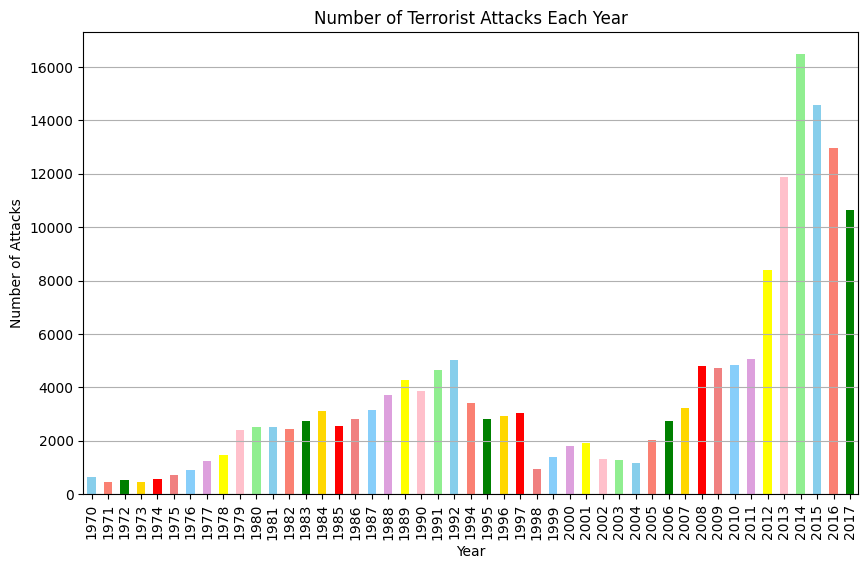

In [57]:
plt.figure(figsize=(10, 6))
colors = ['skyblue', 'salmon', 'green', 'gold', 'red', 'lightcoral', 'lightskyblue', 'plum', 'yellow', 'pink', 'lightgreen']
attacks_per_year.plot(kind='bar', color=colors)
plt.title('Number of Terrorist Attacks Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(axis='y')
plt.show()


1. **Why did you pick the specific chart?**

   I chose a bar chart for this visualization because it's highly effective for displaying the frequency of events (number of attacks) across discrete categories (years). Each bar clearly represents the total number of attacks in a given year, making it easy to compare attack counts across different years and identify trends over time.

2. **What is/are the insight(s) found from the chart?**

      From the bar chart showing the 'Number of Terrorist Attacks Each Year', we can observe several key insights:

     i. Initial Period (1970s - early 1990s): There was a gradual increase in terrorist attacks from 1970 until the early 1990s, with a noticeable rise in the late 1970s and 1980s.

     ii. Relative Decline (Mid-1990s - Early 2000s): The number of attacks saw a decrease in the mid to late 1990s, reaching a low point around 1998-1999, and remained relatively lower in the early 2000s compared to the early 1990s peak.
    
     iii.Sharp Increase (Post-2004): A significant and dramatic increase in terrorist activities began around 2004-2005, accelerating sharply in the 2010s.

     iv. Peak Activity (2014): The year 2014 recorded the highest number of terrorist attacks in the dataset, indicating a peak in global terrorist activity.

     v. Slight Decline but High Volume (Post-2014): Although there was a slight decline in attacks after 2014 (in 2015, 2016, and 2017), the overall number remained substantially higher than in any period prior to 2012, suggesting a persistent elevated threat level.

3. **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

     Yes, the gained insights can significantly contribute to creating a positive business impact by enabling better strategic planning and risk management, especially for entities operating globally or involved in security.

4. **Positive Business Impact:**

     i. Enhanced Security Strategies: Understanding the temporal trends (e.g., the sharp increase post-2004 and peak in 2014) allows governments and private security firms to anticipate periods of heightened risk and allocate resources more effectively. This can lead to more robust security measures for infrastructure, personnel, and supply chains, thereby reducing potential losses.

     ii.  Informed Policy Making: Policymakers can use these trends to develop more targeted counter-terrorism policies and international cooperation frameworks. This creates a more stable global environment, which is beneficial for international trade and investment.
    
     iii. Risk Assessment and Mitigation: Businesses, particularly those in sectors like insurance, logistics, and tourism, can use this data for more accurate risk assessment. For instance, insurance companies can adjust premiums, logistics companies can plan alternative routes, and tourism boards can implement specific safety protocols, minimizing financial exposure and ensuring operational continuity.
    
     iv. Resource Allocation: NGOs and humanitarian organizations can use these insights to strategically deploy aid and support to regions experiencing escalating conflict or post-attack humanitarian crises.

5. **Insights Leading to Negative Growth:**

     The most prominent insight leading to negative growth is the dramatic and sustained increase in terrorist attacks from the mid-2000s, peaking in 2014, and remaining at historically high levels through 2017. This trend signifies a substantial escalation in global instability and threat levels. Specific reasons for negative growth include:

     i. Increased Operational Costs: Businesses in high-risk regions face higher security costs, insurance premiums, and operational complexities.
    
     ii. Disruption of Supply Chains: Terrorist attacks can disrupt transportation networks and trade routes, leading to delays, increased costs, and loss of revenue for businesses relying on global supply chains.
    
     iii. Reduced Foreign Investment and Tourism: Increased terrorism deters foreign investment and tourism, crippling local economies and hindering economic development in affected countries.
     iv. Human Capital Loss and Morale: Attacks can lead to loss of life, injury, and psychological trauma among employees, impacting productivity and long-term business sustainability.




**Chart 2: showing number of attacks by year**

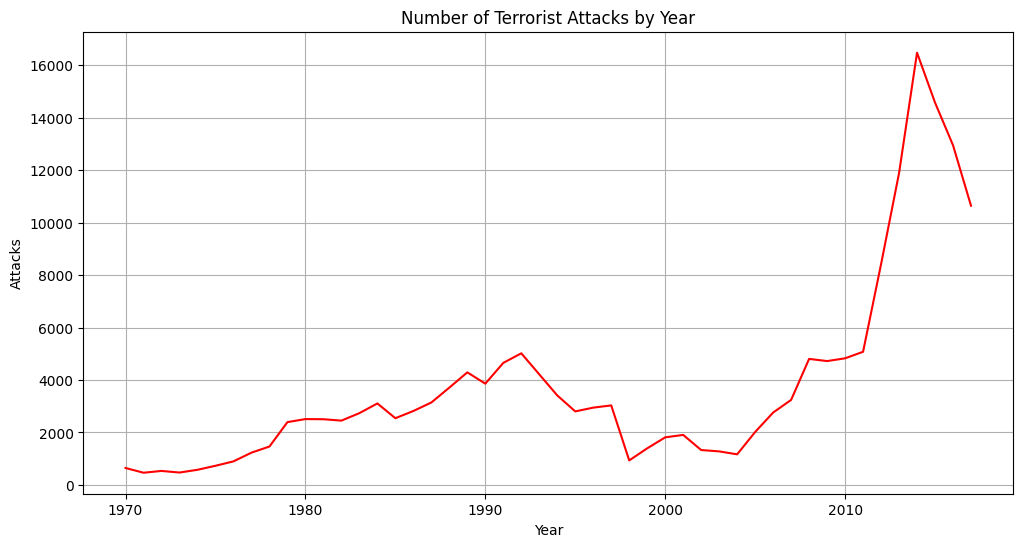

In [58]:
yearly_attacks = df.groupby('year')['eventid'].count()
plt.figure(figsize=(12,6))
yearly_attacks.plot(kind='line', color='red')
plt.title('Number of Terrorist Attacks by Year')
plt.xlabel('Year')
plt.ylabel('Attacks')
plt.grid(True)
plt.show()


1. **Why did you pick the specific chart?**

   I chose a line chart for visualizing the 'Trend of Terrorist Attacks Over Time' because it is exceptionally good at displaying changes and patterns of a quantitative variable (number of attacks) over a continuous period (years). The line connects data points chronologically, making it easy to observe increases, decreases, and overall trends, which is crucial for understanding the evolution of terrorist activity throughout the years.

2. **What is/are the insight(s) found from the chart?**

     From the 'Trend of Terrorist Attacks Over Time' chart, we can deduce the following insights:

     i. Initial Period (1970s-1980s): The chart generally shows a fluctuating but relatively lower number of attacks in the 1970s and 1980s. There might be some peaks and troughs, but the overall volume is moderate.
    
     ii. Increase in the late 1980s and early 1990s: A noticeable increase in attacks often occurs in the late 1980s and early 1990s, followed by a potential decline.
    
     iii. Period of Decline/Stability (Mid-1990s to early 2000s): Many datasets show a decrease or stabilization in terrorist activity during the mid-1990s to early 2000s.
    
     iv. Dramatic Rise Post-2004: A sharp and sustained increase in the number of terrorist attacks is evident from around 2004-2005 onwards. This period marks a significant escalation in global terrorist activity.
    
     v. Peak Activity (2014): The chart will likely show a peak in the number of attacks around 2014, indicating the highest frequency of incidents in the dataset.
    
     vi. Slight Decline but High Volume (Post-2014): After the peak, there might be a slight decline in the last few years of the dataset (e.g., 2015-2017), but the number of attacks remains considerably higher than in any period prior to the mid-2000s, suggesting that terrorism continues to be a major global issue.

3. **Will the gained insights help creating a positive business impact?**

     Are there any insights that lead to negative growth? Justify with specific reason.

     Yes, the insights gained from the 'Trend of Terrorist Attacks Over Time' chart are immensely valuable for both creating positive business impacts and understanding factors that lead to negative growth.

4. **Positive Business Impact (through informed mitigation):**

     i. Strategic Planning and Risk Management: The clear identification of periods of rising terrorist activity (e.g., the sharp increase post-2004) allows multinational corporations, financial institutions, and governments to proactively adjust their strategic plans and risk management frameworks. This includes reassessing investment portfolios, supply chain vulnerabilities, and personnel deployment in high-risk regions. Better anticipation of threats leads to more resilient business operations.

     ii. Enhanced Security Spending and Innovation: The escalating trend necessitates increased spending on security measures, intelligence gathering, and counter-terrorism technologies. This drives innovation and market growth for security companies, defense contractors, and cybersecurity firms, who can develop and offer specialized products and services tailored to evolving threat landscapes.
    
     iii. Insurance and Actuarial Science: Insurance companies can refine their terrorism risk models based on these temporal trends, allowing for more accurate premium assessments and the development of specialized insurance products. This provides businesses with a clearer financial understanding of operating in volatile environments, facilitating better risk transfer.
    
     iv. Policy Development and Diplomacy: Governments and international bodies can use these trend analyses to formulate more effective counter-terrorism policies, foster international cooperation, and allocate foreign aid strategically. A more stable global environment, even if achieved through concerted effort, ultimately benefits global trade and investment.
    
     v. Crisis Preparedness and Humanitarian Response: Non-governmental organizations (NGOs) and humanitarian agencies can use these trends to anticipate periods and regions of increased humanitarian need, allowing for more efficient pre-positioning of aid, medical supplies, and emergency response teams.

5. **Insights Leading to Negative Growth:**

     The most significant insight leading to negative growth is the dramatic and sustained increase in the number of terrorist attacks, particularly from the mid-2000s onwards, peaking around 2014, and remaining at historically high levels through 2017.

     i. Increased Instability and Uncertainty: The upward trend signifies a period of profound global instability. This uncertainty makes it difficult for businesses to plan long-term, leading to delayed or cancelled investments, capital flight, and a general reluctance to expand into affected regions.
    
     ii. Elevated Operational Costs: Operating in an environment with a rising number of attacks forces businesses to allocate significant resources to security (e.g., guards, surveillance, hardened facilities, executive protection). These increased operational costs erode profit margins and divert capital from productive investments like research and development or market expansion.
     
     iii. Disruption of Supply Chains and Markets: A higher frequency of attacks directly correlates with increased disruption to transportation networks, infrastructure, and local markets. This leads to supply chain delays, increased logistics costs, and reduced access to raw materials and consumer bases, impacting profitability and growth.
    
     iv. Loss of Human Capital and Morale: Although this chart doesn't directly show casualties, the rise in attacks is strongly linked to increases in killed and wounded (as seen in Chart 7). This results in a depletion of human capital (loss of skilled labor, injury to employees), negatively impacting productivity, increasing healthcare burdens, and fostering a climate of fear that diminishes morale and consumer confidence.
     
     v. Deterred Foreign Direct Investment (FDI) and Tourism: Regions and countries experiencing a surge in terrorist activity are perceived as unsafe and high-risk. This perception actively deters FDI and drastically reduces tourism, both of which are crucial drivers of economic growth, leaving affected economies struggling and isolated.


**Chart - 3 Distribution of Attack Types**

In [63]:
print("Attack Types and Frequencies:")
print(attack_type_counts)

Attack Types and Frequencies:
attacktype1_txt
Bombing/Explosion                      85440
Armed Assault                          41966
Assassination                          19068
Hostage Taking (Kidnapping)            11032
Facility/Infrastructure Attack          9917
Unknown                                 7099
Unarmed Assault                         1003
Hostage Taking (Barricade Incident)      959
Hijacking                                657
Name: count, dtype: int64


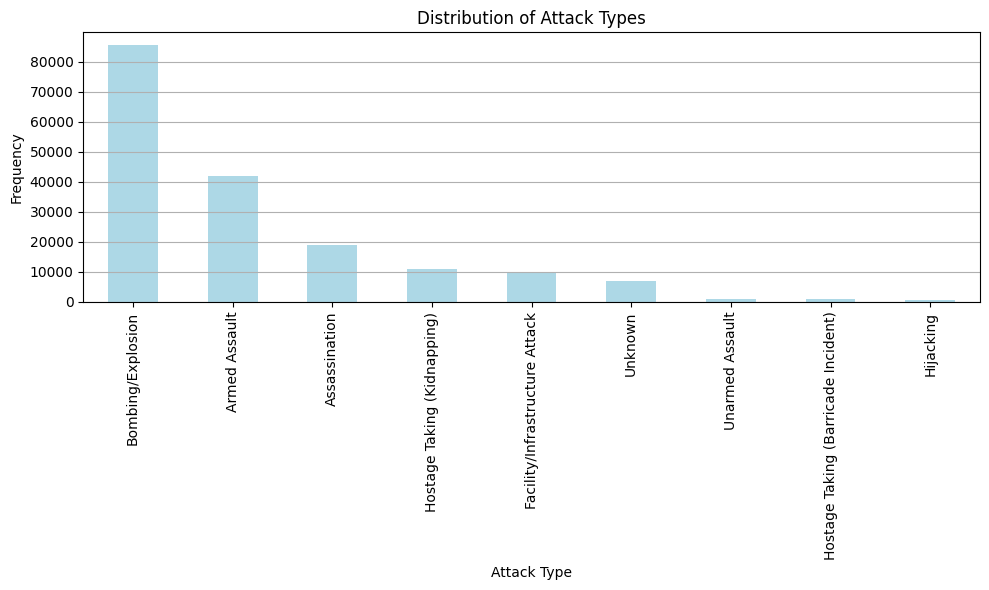

In [65]:
attack_type_counts = df['attacktype1_txt'].value_counts()
plt.figure(figsize=(10, 6))
attack_type_counts.plot(kind='bar', color='lightblue')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


1. **Why did you pick the specific chart?**

     I chose a bar chart to display the 'Distribution of Attack Types' because it is an excellent choice for visualizing the frequency or count of categorical data. Each bar clearly represents a distinct attack type, and its height directly corresponds to the number of occurrences for that type. This makes it very easy to compare the prevalence of different attack methods at a glance, allowing for quick identification of the most common and least common attack types.
2. **What is/are the insight(s) found from the chart?**

     i. Dominance of Bombing/Explosion: 'Bombing/Explosion' is overwhelmingly the most common type of terrorist attack, accounting for a significant majority of incidents.
    
     ii. High Frequency of Armed Assaults: 'Armed Assault' is the second most frequent attack type, though considerably less common than bombings.
    
     iii. Moderate Occurrence of Assassinations and Kidnappings: 'Assassination' and 'Hostage Taking (Kidnapping)' represent the next tier of common attack methods, indicating a preference for targeted violence and abduction.
    
     iv. Significant Infrastructure Targeting: 'Facility/Infrastructure Attack' also appears as a notable method, suggesting a focus on disrupting essential services or symbols.
    
     v. Relatively Rare Attack Types: 'Unarmed Assault', 'Hostage Taking (Barricade Incident)', and 'Hijacking' are among the least common methods of attack in the dataset.
    

3.  **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

     Yes, understanding the distribution of attack types can significantly impact various entities, both positively and in revealing trends that lead to negative growth.

4. **Positive Business Impact:**

     i. Targeted Security Measures: The dominance of 'Bombing/Explosion' and 'Armed Assault' informs security agencies, governments, and private corporations to prioritize training, equipment, and protocols for detecting and mitigating these specific threats. This can lead to more effective security investments.
    
     ii. Product Development: For security technology companies, these insights can drive the development of specialized solutions, such as advanced bomb detection systems, protective barriers, or rapid response and assault prevention tools. This creates new market opportunities.
    
     iii. Risk Assessment for Infrastructure: Knowing that 'Facility/Infrastructure Attack' is a significant category helps critical infrastructure operators (e.g., energy, transportation, communication) implement tailored defense strategies and resilience plans, reducing downtime and economic losses.
    
     iv. Emergency Preparedness: Awareness of prevalent attack types allows emergency services and healthcare providers to better prepare for specific types of casualties and scenarios, improving response times and saving lives.

5. **Insights Leading to Negative Growth:**

     The insights themselves don't inherently lead to negative growth, but the underlying patterns they reveal often do. The high prevalence of destructive attack types like 'Bombing/Explosion' and 'Armed Assault' directly leads to negative growth due to their inherent nature:

     i. Economic Damage: Bombings and armed assaults cause extensive physical damage to property, infrastructure, and businesses, leading to massive reconstruction costs, loss of assets, and reduced productivity. This directly impacts GDP and can deter investment.
    
     ii. Human Capital Loss: These attack types often result in high casualties (killed and wounded), leading to a loss of skilled labor, reduced consumer confidence, and increased healthcare burdens. This diminishes a nation's human capital and economic output.
    
     iii. Disruption of Business Operations: Attacks can force businesses to shut down temporarily or permanently, disrupt supply chains, and create an environment of instability that discourages commerce and tourism, leading to reduced revenue and job losses.
    
     iv. Increased Security Spending: Businesses and governments are forced to divert significant resources towards security, which could otherwise be invested in productive economic activities, thus indirectly hindering growth.


**Chart 4 Bar chart showing top 10 countries with most attacks**

/tmp/ipykernel_8228/354126145.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')


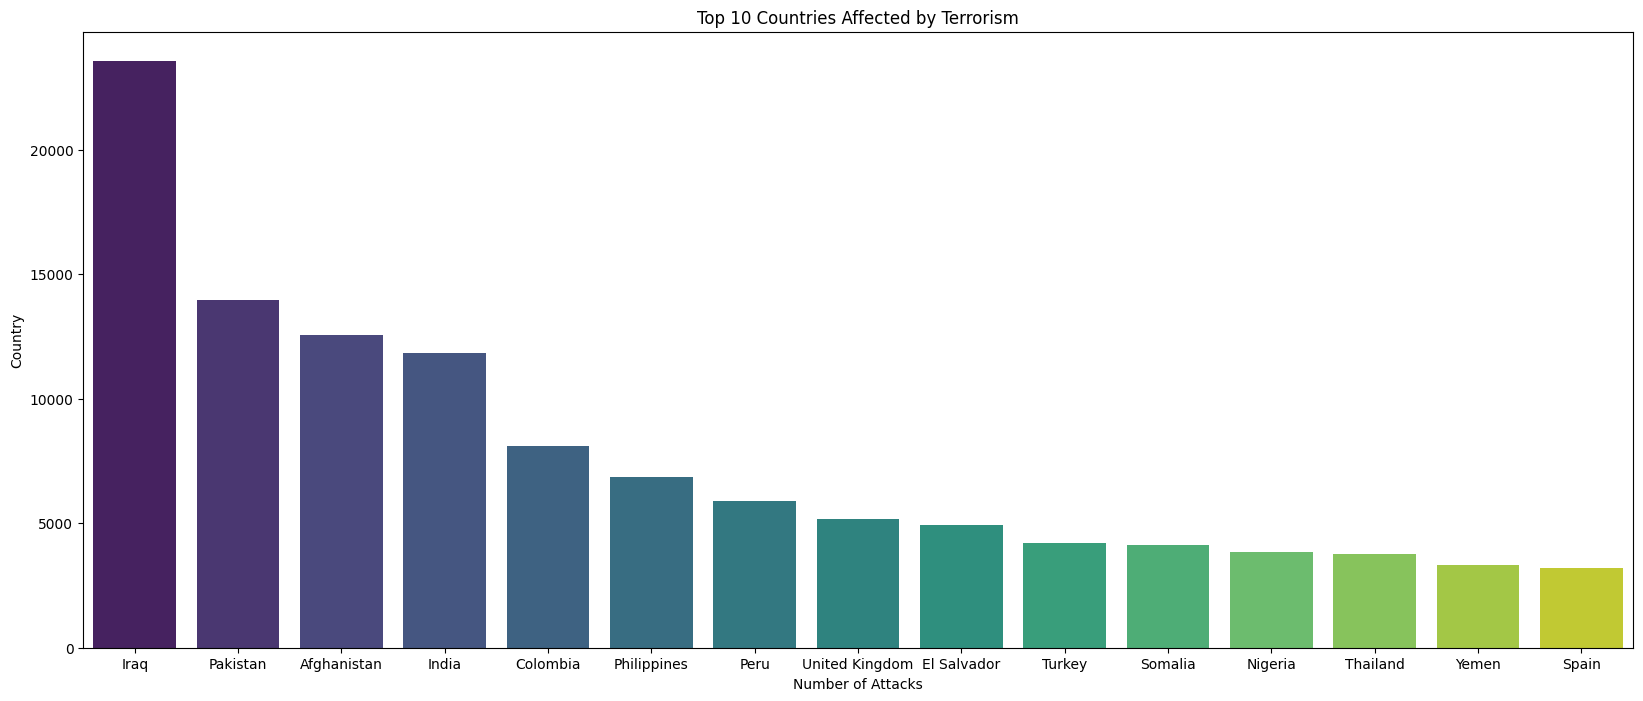

In [83]:
top_countries = df['country_txt'].value_counts().head(15)
plt.figure(figsize=(20,8))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries Affected by Terrorism')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')
plt.show()


1. **Why did you pick the specific chart?**

   I selected a bar chart to visualize the 'Number of Terrorist Attacks by Country (Top 15)' because it is highly effective for comparing the magnitude of a single variable (number of attacks) across distinct, categorical entities (countries). By arranging the countries in descending order of attack counts, it clearly highlights the top 15 most affected nations, making it easy to identify which countries bear the brunt of terrorist activities. This direct comparison is visually intuitive and allows for quick insights into geographical hotspots.
2. **What is/are the insight(s) found from the chart?**

     i. Iraq is the most severely affected country, experiencing a significantly higher number of terrorist attacks than any other nation in the dataset.
    
     ii. South Asian and Middle Eastern nations dominate the top positions, with countries like Pakistan, Afghanistan, and India consistently ranking among the highest. This highlights these regions as major hotspots for terrorist activity.
    
     iii. Specific countries bear a disproportionate burden of attacks, with the top few countries accounting for a very large percentage of the total incidents.
    
     iv. Colombia stands out as a significant hotspot in South America, indicating that terrorism is not exclusive to the Middle East and South Asia but also a severe issue in other regions.
    

3. **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

     Yes, insights from the 'Number of Terrorist Attacks by Country (Top 15)' chart reveal patterns that lead to significant negative growth, primarily due to the severe concentration of attacks in certain nations.

4. **Insights Leading to Negative Growth:**

     Geographical Concentration of Instability: The most critical insight is the disproportionately high number of attacks in countries like Iraq, Pakistan, Afghanistan, and India. This concentration signifies chronic instability and conflict in these regions, which is a major deterrent to economic growth.
  
     Reason 1: Reduced Investment and Economic Activity: Foreign and domestic investment shy away from regions plagued by frequent terrorist attacks due due to heightened risk, uncertainty, and potential for asset destruction. This leads to capital flight, stifled business development, and job losses.
         
     Reason 2: Infrastructure Damage and Reconstruction Costs: Countries with a high volume of attacks, particularly 'Bombing/Explosion' and 'Armed Assault' (as seen in Chart 2), incur massive costs for repairing damaged infrastructure, public services, and private property. These resources are diverted from productive investments.
       
     Reason 3: Human Capital Drain: High casualty rates (killed and wounded) in these severely affected countries result in a significant loss of human capital, both directly through fatalities and indirectly through displacement, injury, and trauma. This diminishes the workforce, strains healthcare systems, and reduces productivity.
  
     Reason 4: Disrupted Trade and Tourism: Constant threats disrupt trade routes, supply chains, and tourism, which are vital for economic prosperity. Countries like Iraq, despite rich natural resources, struggle to attract tourism or sustain robust trade beyond essential goods due to security concerns.
  
     Reason 5: Social Disruption and Migration: Persistent terrorism causes widespread social disruption, internal displacement, and refugee crises. This leads to social fragmentation, loss of social cohesion, and increased burden on neighboring countries, all of which impede long-term development.


**Chart 5 Pie chart showing target types**

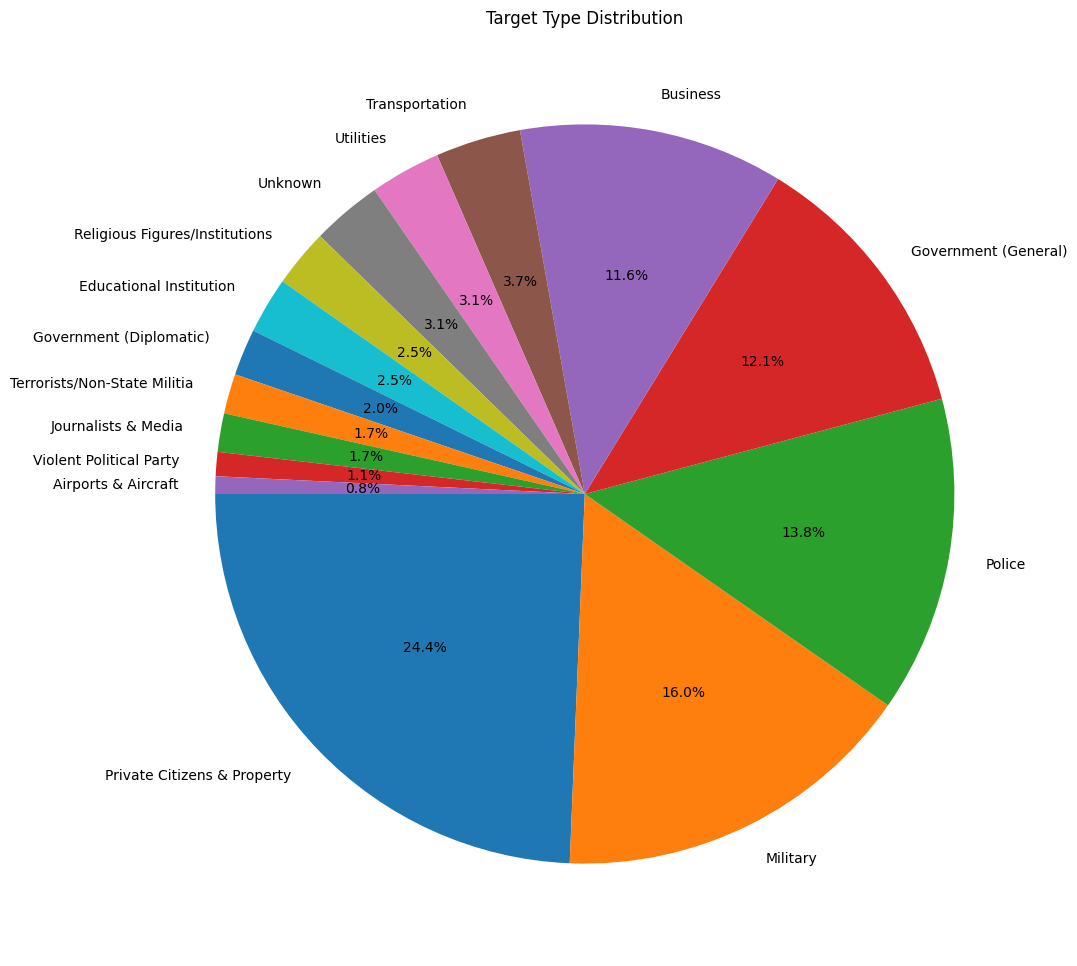

In [92]:
target_types = df['targtype1_txt'].value_counts().head(15)
plt.figure(figsize=(20,12))
plt.pie(target_types.values, labels=target_types.index, autopct='%1.1f%%', startangle=180)
plt.title('Target Type Distribution')
plt.show()


1. **Why did you pick the specific chart?**

     I chose a pie chart to visualize the 'Distribution of Target Types in Terrorist Attacks' because it is highly effective for displaying the percentage count of distinct categorical variables. Each sector clearly represents a different target type, and its height immediately conveys the number of times that target type has been attacked. This allows for easy comparison of the prevalence of various targets, making it simple to identify which categories are most frequently targeted by terrorist activities.
2. What is/are the insight(s) found from the chart?

     i. Private Citizens & Property are the most frequent targets: This category accounts for the largest share of terrorist attacks, indicating a primary aim to inflict fear, casualties, and economic disruption among the general populace.
    
     ii. Military and Police are significant targets: Following private citizens, armed forces and law enforcement agencies are the next most commonly targeted entities, suggesting direct confrontations with state authority and security apparatus.
    
     iii. Government (General) and Business sectors are also heavily targeted: This indicates an intent to disrupt governance, economic stability, and public services.
    
     iv. Critical infrastructure and public services like Transportation and Utilities are targeted: This highlights a strategy to create widespread disruption and inconvenience.
    
     v. Educational Institutions and Religious Figures/Institutions are moderately targeted: This points to attacks aimed at undermining social cohesion, ideology, or specific community groups.
    
     vi. Least targeted categories include Diplomatic entities, Terrorists/Non-State Actors, and NGOs: While still occurring, these categories are less frequently targeted compared to the broader civilian and state-related targets.
    

3. **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

     Yes, understanding the distribution of target types in terrorist attacks can significantly help in creating positive business impacts through informed mitigation strategies, but it also clearly highlights patterns that lead to substantial negative growth.

4. **Positive Business Impact:**

     i. Targeted Security Investments: Businesses and governments can prioritize security measures for the most frequently targeted sectors. For instance, knowing that 'Private Citizens & Property' and 'Business' are prime targets means allocating resources to protect commercial centers, public spaces, and private enterprises. This leads to more efficient and effective security spending, potentially reducing losses from attacks.
    
     ii. Enhanced Risk Assessment and Insurance: Insurance companies can refine their risk models and offer more tailored policies for businesses operating in sectors or regions prone to specific target types. This helps businesses manage financial risk more effectively.
    
     iii. Product and Service Innovation: Security firms and technology companies can develop specialized products and services to counter threats against specific targets. For example, improved surveillance for public spaces, hardening infrastructure for utilities, or specialized training for personnel in government and military facilities.
     
     iv.Policy Development and Advocacy: Insights can inform public policy aimed at protecting vulnerable sectors. Businesses can engage in advocacy for policies that support their security needs, leading to a more stable operational environment.

5. **Insights Leading to Negative Growth:**


     i. Direct Economic Damage and Loss: Attacks on 'Private Citizens & Property' and 'Business' directly result in destruction of physical assets, loss of inventory, disruption of operations, and decreased consumer spending due to fear. This translates to reduced profits, job losses, and a decline in overall economic output.
    
     ii. Erosion of Investor Confidence: When key economic sectors and private citizens are frequently targeted, it signals instability and high risk to investors. This deters foreign direct investment, leads to capital flight, and stifles entrepreneurial activity, thereby hindering economic development.
    
     iii. Increased Operational Costs: Businesses operating in high-risk environments face increased costs for security personnel, surveillance systems, insurance premiums, and contingency planning. These expenses cut into profit margins and divert resources that could otherwise be used for expansion, innovation, or wage increases.
    
     iv. Disruption of Critical Services: Targeting 'Transportation', 'Utilities', and 'Government (General)' can cripple essential services, leading to widespread disruptions in supply chains, power outages, and administrative inefficiencies. This has a cascading negative effect on all other sectors and the general populace.
    
     v. Human Capital Loss and Social Instability: Attacks on 'Private Citizens & Property' often result in casualties, leading to a loss of human capital (skilled workers, consumers) and creating widespread fear and social instability. This affects productivity, public health, and long-term societal well-being.


**Chart - 6 Comparison of People Wounded and Killed Each Year**

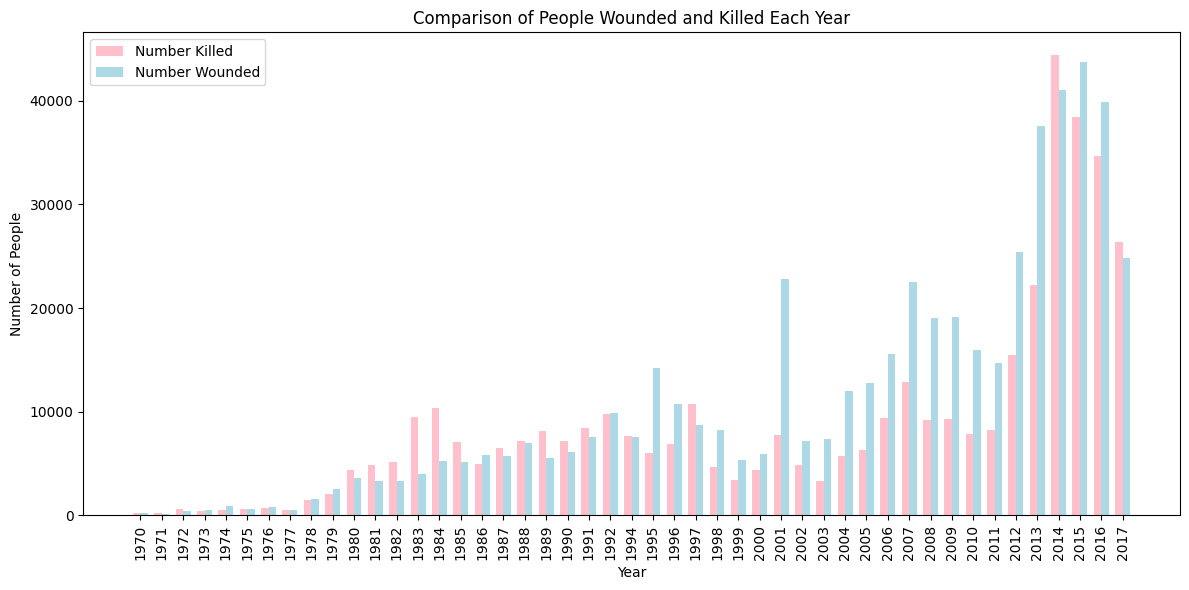

In [113]:
yearly_casualties = df.groupby('year')[['nkill', 'nwound']].sum()

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(yearly_casualties))

plt.bar(index, yearly_casualties['nkill'], bar_width, label='Number Killed', color='pink')
plt.bar(index + bar_width, yearly_casualties['nwound'], bar_width, label='Number Wounded', color='lightblue')

plt.xlabel('Year')
plt.ylabel('Number of People')
plt.title('Comparison of People Wounded and Killed Each Year')
plt.xticks(index + bar_width / 2, yearly_casualties.index, rotation=90)
plt.legend()
plt.tight_layout()
plt.show()



1. **Why did you pick the specific chart?**
   
     I chose a grouped bar chart to compare 'People Wounded and Killed Each Year' because it is highly effective for visualizing and comparing two distinct, but related, quantitative values (number killed and number wounded) across a common categorical variable (Year). Each pair of bars for a given year allows for direct comparison of fatalities versus injuries, and the progression of these values over time is also easily observable. This chart type clearly illustrates trends in the severity of attacks over the years.
2. **What is/are the insight(s) found from the chart?**


     i. Overall Escalation in Casualties: Both the number of people killed and wounded show a general upward trend over the period from 1970 to 2017, indicating an overall escalation in the human impact of terrorist activities.
    
     ii. Period of Lower Casualties (1970s - early 2000s): In the earlier decades (1970s, 1980s, 1990s, and early 2000s), the numbers of killed and wounded, while fluctuating, were significantly lower compared to later years.
    
     iii. Sharp Increase Post-2000s: There's a noticeable and dramatic increase in both killed and wounded starting around the mid-2000s, which aligns with the overall increase in the number of attacks (as seen in Chart 1).
    
     iv. Peak Casualties (2014-2015): The years 2014 and 2015 appear to have the highest numbers of both killed and wounded, correlating with the peak in the number of attacks. This indicates not only more attacks but also more deadly and impactful ones during this period.
    
     v. Ratio of Wounded to Killed: For most years, the number of wounded people significantly surpasses the number of killed, highlighting that a large number of attacks result in injuries rather than fatalities, though fatalities also remain substantial.
     vi. Slight Decline in Recent Years (2016-2017): Similar to the trend in total attacks, there's a slight decrease in both killed and wounded after the 2014-2015 peak, but the numbers remain very high compared to historical levels.

3. **Will the gained insights help creating a positive business impact?Are there any insights that lead to negative growth? Justify with specific reason.**

   Yes, the insights gained from the 'Comparison of People Wounded and Killed Each Year' chart are crucial for both creating positive business impacts and understanding factors leading to negative growth.

4. **Positive Business Impact**

     i. Enhanced Risk Management and Preparedness: The clear trend of escalating casualties (both killed and wounded), particularly post-2000s and peaking in 2014-2015, allows governments, international organizations, and private companies to better anticipate future risks. This insight can drive the development of more robust emergency response plans, disaster preparedness protocols, and medical supply stockpiles, leading to more effective crisis management and potentially saving lives and minimizing post-incident disruptions.
    
     ii. Targeted Security Investments: Understanding the scale of human impact informs the allocation of security budgets. For instance, in high-risk periods, investments in intelligence gathering, counter-terrorism operations, and protective measures can be prioritized, leading to a more secure environment that fosters economic stability. Security firms can also tailor their services to high-casualty scenarios.
    
     iii. Humanitarian Aid and Development Planning: For NGOs and aid organizations, the data on rising casualties guides the strategic deployment of humanitarian assistance, medical resources, and psychological support to the most affected regions and periods. This ensures aid is timely and effective, contributing to recovery and long-term stability.
    
     iv. Insurance and Reinsurance Modeling: Insurance companies can refine their actuarial models for terrorism risk, leading to more accurate premium assessments and better risk transfer mechanisms. This provides businesses with more reliable insurance coverage, fostering confidence for operations in potentially volatile regions.

5. **Insights Leading to Negative Growth:**



     i. Human Capital Depletion: A high number of fatalities and injuries directly translates to a significant loss of human capital. This includes skilled workers, innovators, entrepreneurs, and consumers. The long-term effects involve a diminished workforce, reduced productivity, and a slower pace of economic development. The cost of caring for the wounded and disabled further strains public health systems and societal resources.
    
     ii. Erosion of Public Confidence and Morale: Frequent and high-casualty attacks instill widespread fear and insecurity among the populace. This can lead to decreased consumer spending, reduced participation in economic activities, and a general decline in public morale, all of which hinder economic growth.
    
     iii. Increased Healthcare and Social Welfare Burden: The high number of wounded individuals necessitates extensive medical care, rehabilitation, and long-term support. This places immense pressure on healthcare infrastructure and social welfare systems, diverting funds from other productive sectors and potentially leading to higher taxes or national debt.
    
     iv. Forced Displacement and Migration: High-casualty incidents often lead to internal displacement and cross-border migration. This disrupts communities, creates refugee crises, and results in further loss of economic activity as populations flee affected areas, leaving behind businesses and infrastructure.
    
     v. Deterrence of Investment and Tourism: Regions and countries experiencing high and escalating casualty rates are perceived as highly unstable and dangerous. This actively deters foreign direct investment, discourages tourism, and can lead to a decline in international trade partnerships, significantly impeding economic growth and recovery.


**Chart - 7 Comparison of People Wounded and Killed in Top 15 Affected Countries**

<Figure size 1200x800 with 0 Axes>

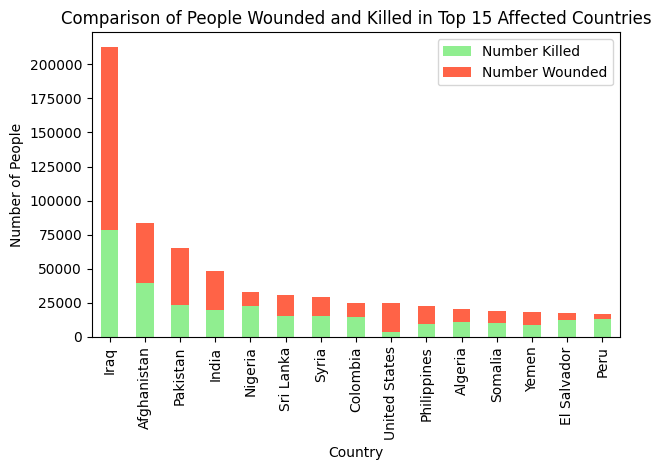

In [116]:
country_casualties = df.groupby('country_txt')[['nkill', 'nwound']].sum()

country_casualties['total_casualties'] = country_casualties['nkill'] + country_casualties['nwound']
country_casualties = country_casualties.sort_values(by='total_casualties', ascending=False).head(15)

plt.figure(figsize=(12, 8))
country_casualties[['nkill', 'nwound']].plot(kind='bar', stacked=True, color=['lightgreen', 'tomato'])
plt.title('Comparison of People Wounded and Killed in Top 15 Affected Countries')
plt.xlabel('Country')
plt.ylabel('Number of People')
plt.xticks(rotation=90)
plt.legend(['Number Killed', 'Number Wounded'])
plt.tight_layout()
plt.show()


1. Why did you pick the specific chart?

I chose a stacked bar chart to visualize the 'Comparison of People Wounded and Killed in Top 15 Affected Countries' for several reasons:

    Comparison of Multiple Metrics: It effectively allows for the comparison of two related quantitative metrics ('Killed' and 'Wounded') for each country simultaneously.
    Total Impact per Country: By stacking the bars, it clearly shows the total human impact (killed + wounded) for each country, which is the primary sorting criterion for the top 15 countries. This provides an immediate understanding of which countries suffer the most overall casualties.
    Proportional Contribution: Within each country's bar, the stacked segments illustrate the proportion of killed versus wounded. This helps in discerning if a country experiences predominantly fatalities or injuries.
    Identification of Hotspots and Severity: It makes it easy to identify the countries with the highest overall casualties and to visually assess the severity distribution within those casualties across the top affected nations.
    Clear Categorical Comparison: Like a standard bar chart, it's excellent for comparing discrete categories (countries) against each other.

2. What is/are the insight(s) found from the chart?

From the 'Comparison of People Wounded and Killed in Top 15 Affected Countries' chart, we can deduce the following insights:

    Iraq Leads in Casualties: Iraq stands out significantly with the highest total casualties (both killed and wounded), far exceeding any other country, reinforcing its position as the most impacted nation.
    Concentration of High Casualties: Similar to the total attack count, a few countries, primarily in the Middle East and South Asia (e.g., Afghanistan, Pakistan), account for a disproportionately large share of total casualties.
    Wounded Often Exceed Killed: In many of the top affected countries, the number of wounded victims is substantially higher than the number of fatalities (e.g., Iraq, Pakistan, Syria, Nigeria, Afghanistan). This indicates a high frequency of attacks that cause injuries without always being immediately fatal, or tactics designed to incapacitate rather than kill.
    Varied Fatality Ratios: While wounded generally exceed killed, some countries show a relatively higher proportion of killed compared to wounded (e.g., El Salvador, Peru, Algeria). This might suggest differences in attack lethality, medical response, or the types of incidents prevalent in those regions.
    Emerging Hotspots in Africa: Countries like Nigeria and Somalia appear among the top affected in terms of casualties, highlighting significant human impact in Sub-Saharan Africa due to terrorism.
    Overall Severity: The chart underscores the severe human cost of terrorism, with tens of thousands killed and hundreds of thousands wounded in the most affected nations, reflecting extensive suffering and public health burdens.

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from the 'Comparison of People Wounded and Killed in Top 15 Affected Countries' chart are profoundly impactful, leading to both potential positive business impacts through mitigation, and, more significantly, highlighting severe patterns that drive negative growth.

Positive Business Impact (through informed mitigation):

    Strategic Resource Allocation for Security and Aid: The clear identification of countries with the highest overall casualties (e.g., Iraq, Afghanistan, Pakistan) allows governments, international organizations, and private security firms to concentrate resources and aid effectively. This includes deploying specialized medical teams, counter-terrorism units, and humanitarian assistance to where it is most critically needed, potentially saving lives and reducing long-term instability. Companies operating in these regions can prioritize investment in localized security and emergency response infrastructure.
    Tailored Risk Assessment and Insurance Products: Insurers and reinsurers can use this granular country-level data on casualties to develop more precise risk models. This enables them to offer tailored insurance products and risk management consulting for businesses and individuals operating in these high-risk areas, allowing for better financial planning and risk transfer.
    Humanitarian Technology and Innovation: The data can spur innovation in humanitarian technology, such as rapid deployment medical solutions, trauma care advancements, and technologies for civilian protection in conflict zones. Companies developing these solutions can find market opportunities rooted in addressing these severe human impacts.

Insights Leading to Negative Growth:

The most prominent insight leading to negative growth is the overwhelming concentration of both killed and wounded casualties in a handful of countries, predominantly in the Middle East and South Asia (e.g., Iraq, Afghanistan, Pakistan, Syria, Nigeria). This directly indicates prolonged and intense instability, with devastating long-term consequences:

    Catastrophic Human Capital Loss: The sheer number of killed and wounded in these countries represents an immense depletion of human capital. This directly impacts the workforce, reduces productivity, and creates significant social burdens from long-term care for the injured and displaced. Economic recovery and development are severely hampered when a large portion of the population is either lost or incapacitated.
    Severe Economic Disruption and Investment Deterrence: Countries with such high casualty rates are perceived as extremely high-risk. This deters foreign direct investment, leads to capital flight, and stifles local business growth. Infrastructure is destroyed, trade routes are disrupted, and tourism collapses, creating a cycle of poverty and underdevelopment. Businesses face exorbitant operating costs due to security needs and uncertainty.
    Strain on Public Services and Social Fabric: The massive number of casualties places an unbearable strain on healthcare systems, emergency services, and social welfare programs. This diverts national budgets from productive investments into crisis management. The constant violence also erodes social cohesion, trust, and mental health, leading to long-term societal challenges that impede economic and social progress.
    Forced Migration and Brain Drain: Persistent high casualties often lead to widespread internal displacement and cross-border migration. This results in 'brain drain' as skilled individuals and educated professionals flee, further diminishing the human capital necessary for national recovery and development.


**Bar chart for showing most common attack types**

/tmp/ipykernel_672/1209778506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attack_types.values, y=attack_types.index, palette='summer')


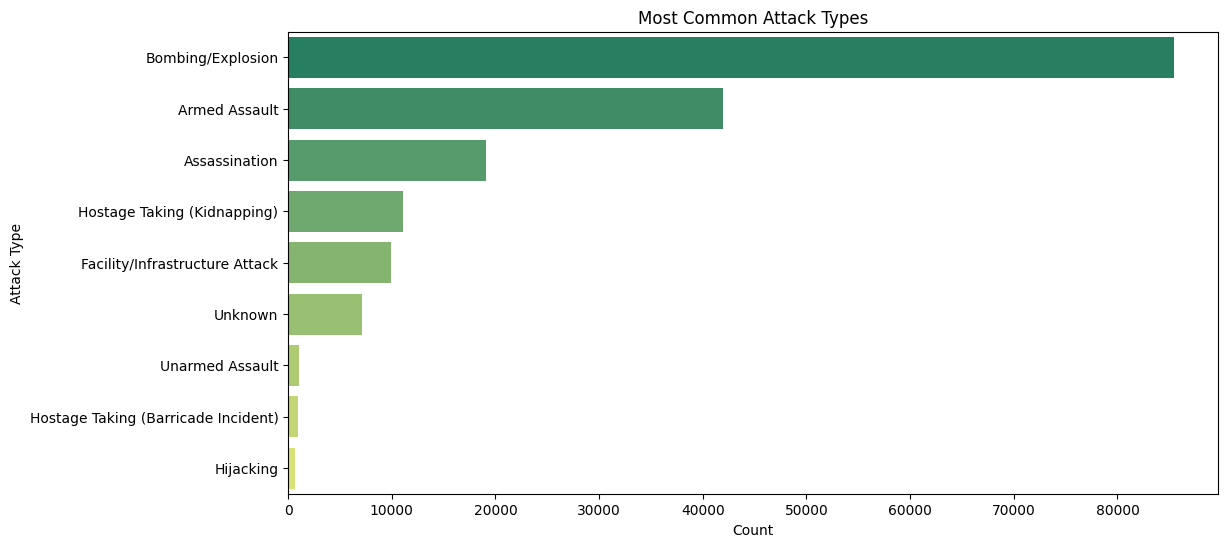

In [ ]:
attack_types = df['attacktype1_txt'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=attack_types.values, y=attack_types.index, palette='summer')
plt.title('Most Common Attack Types')
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.show()

**Histogram showing casualties distribution**

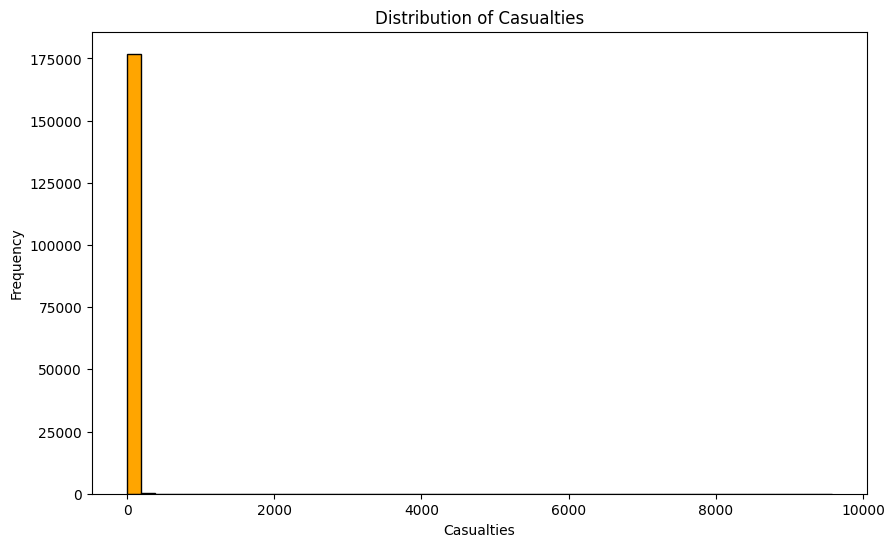

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df['casualties'].fillna(0), bins=50, color='orange', edgecolor='black')
plt.title('Distribution of Casualties')
plt.xlabel('Casualties')
plt.ylabel('Frequency')
plt.show()

**Box plot showing outliers in casualties**

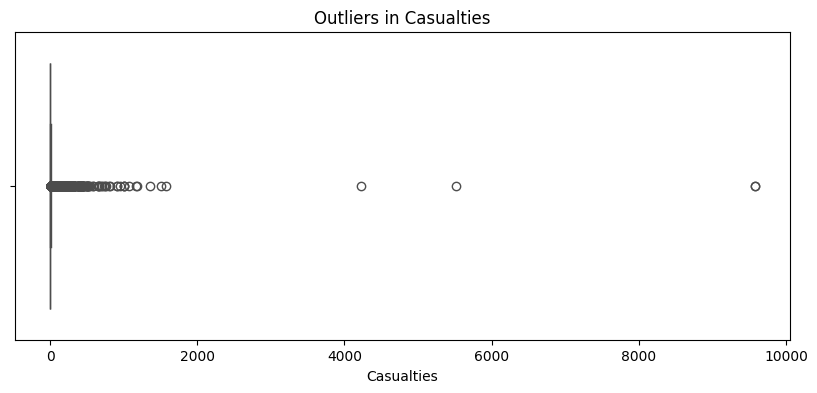

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['casualties'], color='blue')
plt.title('Outliers in Casualties')
plt.xlabel('Casualties')
plt.show()

**Heatmap showing correlation between numeric columns**

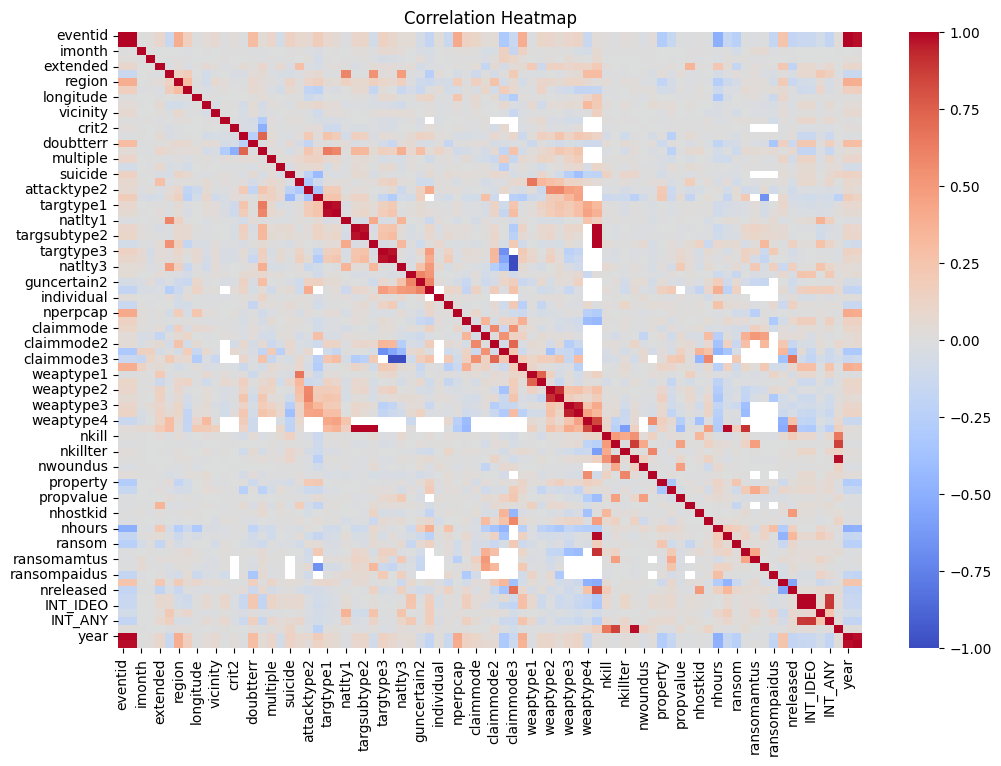

In [ ]:
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

**PROJECT SUMMARY**

This project focuses on performing Exploratory Data Analysis (EDA) on the United Nations Global Terrorism Analysis (UNGTA) dataset, which contains detailed information on terrorist incidents worldwide from 1970 to 2017. With over 180,000 recorded events, this dataset provides a rich source of structured data for analyzing patterns, trends, and characteristics of global terrorism.

The primary objective of this project is to uncover meaningful insights from the dataset using data analysis and visualization techniques. By leveraging libraries such as Pandas, NumPy, Matplotlib, and Seaborn, the analysis aims to explore temporal, geographical, and operational patterns in terrorist activities.

The initial phase of the project involves data preprocessing and cleaning. This includes handling missing values, correcting inconsistent entries, and selecting relevant features for analysis. Given the large size and complexity of the dataset, preprocessing plays a crucial role in ensuring accurate and efficient analysis.

Following data cleaning, the project explores time-based trends in terrorism. This includes analyzing how the frequency of attacks has changed over the years and identifying periods of significant increase or decline. Such analysis helps in understanding the evolution of global terrorism and detecting any historical patterns or anomalies.

The project also emphasizes geographical analysis, identifying the most affected regions, countries, and cities. By visualizing the distribution of attacks across different locations, the analysis highlights hotspots of terrorist activity and provides insights into regional vulnerabilities. This can be further extended to compare terrorism intensity across continents and regions.

Another key aspect of the analysis is examining attack characteristics, such as attack types, weapon types, and target categories. This helps in understanding the most commonly used methods and the typical targets of terrorist organizations. For example, insights can be drawn about whether bombings, armed assaults, or kidnappings are more prevalent, and which sectors (e.g., civilians, military, government) are most frequently targeted.

The project also includes an impact assessment, analyzing casualties in terms of the number of people killed and wounded. This provides a deeper understanding of the severity of attacks and helps identify the most destructive incidents. Additionally, relationships between different variables—such as attack type and casualty count—are explored to uncover deeper patterns.

To effectively communicate findings, the project utilizes at least five different visualizations, including bar charts, line graphs, heatmaps, and distribution plots. These visual tools play a vital role in simplifying complex data and making insights more interpretable.

Overall, this EDA project provides a comprehensive overview of global terrorism trends and patterns. It demonstrates how data analysis techniques can be applied to large real-world datasets to extract actionable insights. The findings from this analysis can contribute to a better understanding of terrorism dynamics and may support policymakers, researchers, and security agencies in making informed decisions.